# Blending Data from Multiple Sources

This is an example showing how to process data from three data sources. We will be showing how to work with two similar data sets that can be merged, and how to deal with a source that can't be easily merged.

The first of the two "mergeable" datasets is the surface global irradiance from the Himawari satellite. This data is masked over the ocean away from the coast, and it also has a slightly different grid spacing to the ACCESS model data. 

The second of the two "mergable" datasets is the ACCESS model data, from which we will extract the mean sea level pressure. This is a generally compatible region (lat/lon bounding box), but has a slightly different grid spacing.

The third data set is radar data from one radar in the Australian region. It only has X and Y coordinates, so it's not straightforward to create a simple merged data sets.

In all these examples, a simple linear interpolation is used for merging datasets. More complex merge operations are possible.

### Himawari Data

The tutorial will first introduce a single data set. Datasets can be merged using a pre-defined grid (such as a Mercator projection with a specified grid spacing), or, and this is often simplest, one of the datasets can be used to define the target grid structure without needing a formal specification of it. Let's examine the Himawari data now.

In [1]:
%%capture

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import tempfile
import site_archive_nci

In [2]:
# We specify the date, hour, and minute for querying data
doi = '2021-06-09T0600'  

In [3]:
himawari = petdata.archive.Himawari('surface_global_irradiance')

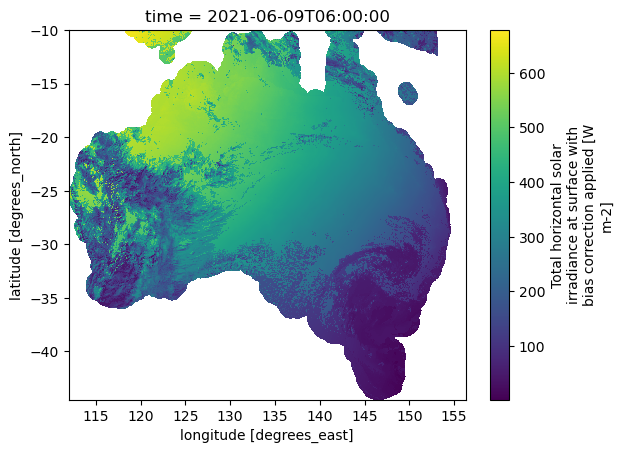

In [4]:
sample_sgi = himawari[doi].surface_global_irradiance
sample_sgi.plot()

In [5]:
# Uncomment the line below to see the data structure
# sample_sgi

### ACCESS Model Data

Here we see how to access a single sample of ACCESS model data

In [6]:
# We want the ACCESS data trimmed to the same bounding box as the Himawari data.
# The ACCESS data is global, but we only want the Australian region
like_himawari = petdata.transform.region.like(sample_sgi) 
access_g = petdata.archive.ACCESS( variables='sfc/mslp', datatype='an', region='g',transforms=like_himawari)

In [7]:
%%capture
sample_mslp = access_g[doi].mslp

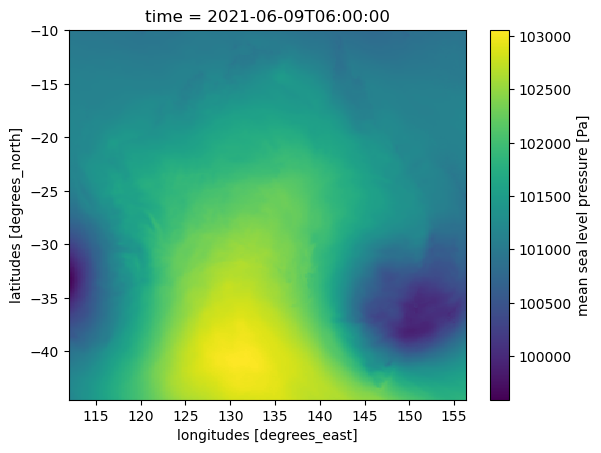

In [8]:
sample_mslp.plot()

### Radar Data

The radar data sample comes from just a single radar, and its geospatial data is not known. We can retrieve samples by date, but it's not easy to geolocate them. Let's examine some data.

In [9]:
radar = petdata.archive.RadarDemo(variables='RAIN')

In [10]:
radar_sample = radar[doi]
radar_sample

<xarray.Dataset> Size: 68kB
Dimensions:                     (y: 128, x: 128)
Coordinates:
  * x                           (x) float64 1kB -1.27e+05 -1.25e+05 ... 1.27e+05
  * y                           (y) float64 1kB -1.27e+05 -1.25e+05 ... 1.27e+05
    ProjectionCoordinateSystem  int32 4B ...
    projection                  int32 4B ...
Data variables:
    RAIN                        (y, x) float32 66kB dask.array<chunksize=(128, 128), meta=np.ndarray>
Attributes: (12/13)
    radar_name:          
    nradar:              1
    Conventions:         CF/Radial instrument_parameters
    version:             H5rad 2.2
    title:               
    institution:         
    ...                  ...
    source:              RAD:AU71,PLC:T/Hills,CTY:500,STN:66210
    history:             
    comment:             
    instrument_name:     
    original_container:  odim_h5
    odim_conventions:    ODIM_H5/V2_2

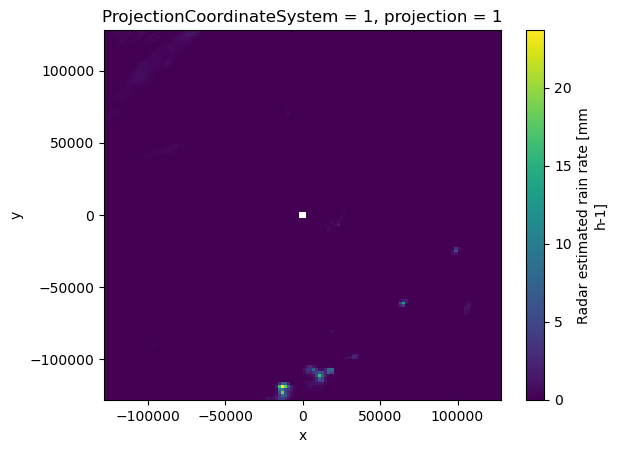

In [11]:
radar_sample.RAIN.plot()

## Putting them together, the simple way, without "merging" them

Despite their differences, these data sources can easily be co-indexed. If all you want to do is retrieve the relevant samples by date, than can be done quickly and easily using a pipeline.

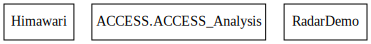

In [12]:
pipe = petpipe.Pipeline(
    (himawari, access_g, radar),
)
pipe

In [13]:
%%capture
all_sources = pipe[doi]

In [14]:
# Indexing into the pipeline by the data of interest returns a tuple, with
# the retrieved item from each data source according to that data of interest
print(type(all_sources))
print(len(all_sources))

<class 'tuple'>
3


In [15]:
all_sources[2]  # 

<xarray.Dataset> Size: 68kB
Dimensions:                     (y: 128, x: 128)
Coordinates:
  * x                           (x) float64 1kB -1.27e+05 -1.25e+05 ... 1.27e+05
  * y                           (y) float64 1kB -1.27e+05 -1.25e+05 ... 1.27e+05
    ProjectionCoordinateSystem  int32 4B ...
    projection                  int32 4B ...
Data variables:
    RAIN                        (y, x) float32 66kB dask.array<chunksize=(128, 128), meta=np.ndarray>
Attributes: (12/13)
    radar_name:          
    nradar:              1
    Conventions:         CF/Radial instrument_parameters
    version:             H5rad 2.2
    title:               
    institution:         
    ...                  ...
    source:              RAD:AU71,PLC:T/Hills,CTY:500,STN:66210
    history:             
    comment:             
    instrument_name:     
    original_container:  odim_h5
    odim_conventions:    ODIM_H5/V2_2

The coordinates of the radar data are specified as "X" and "Y". Because the radar data has X and Y, we have no way to correlate it with the latitude and longitude dimensions of the Himawari and ACCESS data.

## Merging datasets onto a common grid

(Please note! There is no reason to assume that you want the data on a common grid for machine learning. Many ML algorithms are happy with (and may prefer) unhomogenised data!)

It can be useful to try to merge data sources onto a common grid, so that they all have data at the exact same spots. For example, consider the following data sets:

```
x1=[1,  3,   6,   9, 10],   y1=[1, 9, 36, 81, 100]
x2=[1, 2, 4, 6, 8,   10],   y2=[1, 4, 16, 64, 100]
```

They both fulfil y=x^2, but with slightly different coordinates, but both ranging from 1 to 10 inclusive. The semantics of the ordinal indexing (place value) do not match the semantics of the cadinal indexing (the actual value of the coordinate). It can be really useful to line up two datasets with the same x values. When doing so, it's necessary to guess the corresponding y value in some fashion. In leiu of a clear formula, a linear interpolation of the y values is used.

Either both y1 and y2 could each be interpolated to provide values for, say x=`[1,2,3,4,5,6,7,8,9,10]`, or y1 could be interpolated to give values for the x1 coordinates.

In earth system modelling terms, the most common interpolation is between coordinate reference systems, possibly including different spatial resolutions. "x" in that case is the latitude and longitude values, and "y" would be the data values.

PyEarthTools supports a number of transformations. This notebook demonstrates the "InterpLike" transformation which will map one dataset onto the coordinates of another using linear interpolation.

The first step will be looking at merging Himawari with ACCESS, and then subsequently we will look at how to deal with the fact the radar data cannot be simply merged.

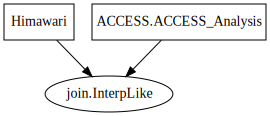

In [16]:
pipe = petpipe.Pipeline(
    (himawari, access_g),
    petpipe.operations.xarray.join.InterpLike(sample_mslp[0])
)
pipe

In [17]:
%%capture
merged_sample = pipe[doi]


In [18]:
merged_sample

<xarray.Dataset> Size: 894kB
Dimensions:                    (time: 1, latitude: 295, longitude: 252)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T06:00:00
  * latitude                   (latitude) float32 1kB -10.02 -10.14 ... -44.47
  * longitude                  (longitude) float32 1kB 112.1 112.2 ... 156.2
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 595kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
    mslp                       (time, latitude, longitude) float32 297kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:13 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

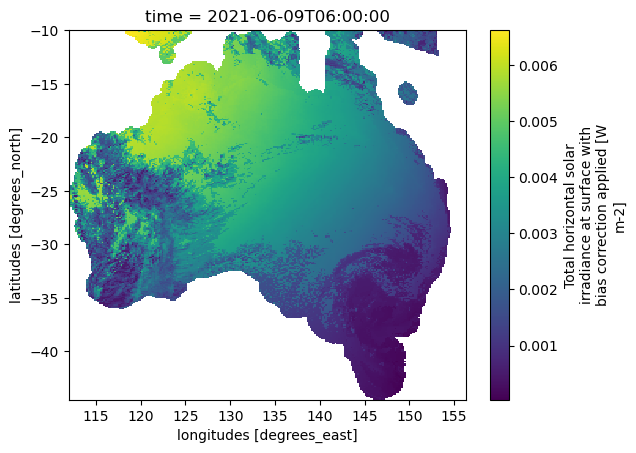

In [19]:
# If we want to, we can now operate on the samples with a common grid
(merged_sample.surface_global_irradiance / merged_sample.mslp).plot()

## Pipelines with Unmergeable Data

In this example, we will merge the Himawari and ACCESS data into a dataset which has a common coordinate reference system, but leave the radar data to be indexed separately. Each request to the pipeline according to the date of interest will return the merged data, together with the relevant unmerged data, as a tuple. The user is then able to interpret each data source as they wish.

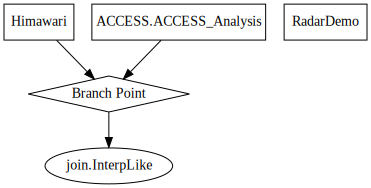

In [20]:
pipe = petpipe.Pipeline(
    (himawari, access_g),
    (petpipe.operations.xarray.join.InterpLike(sample_mslp[0]), radar)
)
pipe

In [21]:
%%capture
sample = pipe[doi]

In [22]:
sample[0]

<xarray.Dataset> Size: 894kB
Dimensions:                    (time: 1, latitude: 295, longitude: 252)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T06:00:00
  * latitude                   (latitude) float32 1kB -10.02 -10.14 ... -44.47
  * longitude                  (longitude) float32 1kB 112.1 112.2 ... 156.2
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 595kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
    mslp                       (time, latitude, longitude) float32 297kB dask.array<chunksize=(1, 295, 252), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:13 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [23]:
sample[1]

<xarray.Dataset> Size: 68kB
Dimensions:                     (y: 128, x: 128)
Coordinates:
  * x                           (x) float64 1kB -1.27e+05 -1.25e+05 ... 1.27e+05
  * y                           (y) float64 1kB -1.27e+05 -1.25e+05 ... 1.27e+05
    ProjectionCoordinateSystem  int32 4B ...
    projection                  int32 4B ...
Data variables:
    RAIN                        (y, x) float32 66kB dask.array<chunksize=(128, 128), meta=np.ndarray>
Attributes: (12/13)
    radar_name:          
    nradar:              1
    Conventions:         CF/Radial instrument_parameters
    version:             H5rad 2.2
    title:               
    institution:         
    ...                  ...
    source:              RAD:AU71,PLC:T/Hills,CTY:500,STN:66210
    history:             
    comment:             
    instrument_name:     
    original_container:  odim_h5
    odim_conventions:    ODIM_H5/V2_2